## Importing Libraries:

In [1]:
%%time 
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

CPU times: total: 5.5 s
Wall time: 5.72 s


## Load MNIST:

In [2]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

## Create a baseline model:

In [3]:
def create_model():
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation="relu"),
        Dense(10,activation="softmax")
    ])
    model.compile(optimizer="adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
    )
    return model

## Create a model:

In [4]:
model = create_model()

## Train the **baseline** model:

In [5]:
history_baseline = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8443 - loss: 2.8372 - val_accuracy: 0.8940 - val_loss: 0.5286
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9009 - loss: 0.4218 - val_accuracy: 0.9196 - val_loss: 0.3875
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9248 - loss: 0.2994 - val_accuracy: 0.9277 - val_loss: 0.2840
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9350 - loss: 0.2527 - val_accuracy: 0.9343 - val_loss: 0.2828
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9364 - loss: 0.2504 - val_accuracy: 0.9372 - val_loss: 0.2780
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9430 - loss: 0.2275 - val_accuracy: 0.9452 - val_loss: 0.2370
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9477 - loss: 0.2065 - val_accuracy: 0.9454 - val_loss: 0.2606
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9509 - loss: 0.1940 -

# **Normalized Data**

In [6]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()
X_train,X_test = X_train/255.0,X_test/255.0

## Create Normalized model:

In [7]:
def create_model_with_norm_model():

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128,activation="relu"),
        Dense(10,activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## Train normalized model:

In [8]:
model_with_norm_data = create_model_with_norm_model()

history_norm_data = model_with_norm_data.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9201 - loss: 0.2831 - val_accuracy: 0.9518 - val_loss: 0.1643
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9634 - loss: 0.1259 - val_accuracy: 0.9665 - val_loss: 0.1126
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9737 - loss: 0.0871 - val_accuracy: 0.9691 - val_loss: 0.1050
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.9729 - val_loss: 0.0912
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9737 - val_loss: 0.0890
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9753 - val_loss: 0.0910
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9749 - val_loss: 0.0856
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9929 - loss: 0.02

# **Plot normalization effect**

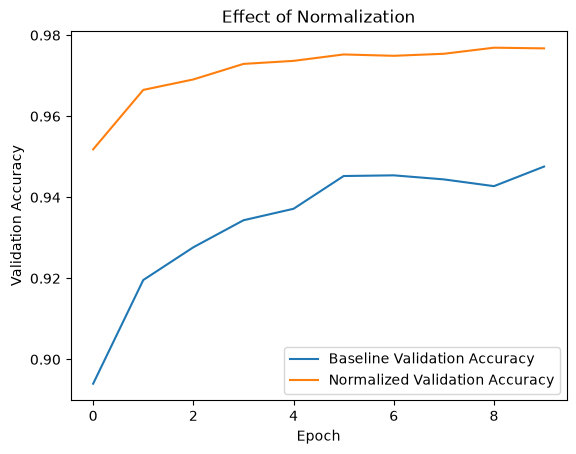

In [9]:
plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline Validation Accuracy'
)

plt.plot(
    history_norm_data.history['val_accuracy'],
    label='Normalized Validation Accuracy'
)

plt.title('Effect of Normalization')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

## **Dropout**

In [10]:
def create_model_with_dropout():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        Dense(10,activation="softmax")
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Train dropout model:

In [11]:
model_with_dropout = create_model_with_dropout()

history_dropout = model_with_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8721 - loss: 0.4329 - val_accuracy: 0.9460 - val_loss: 0.1874
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9308 - loss: 0.2371 - val_accuracy: 0.9598 - val_loss: 0.1403
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9412 - loss: 0.2008 - val_accuracy: 0.9646 - val_loss: 0.1199
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9477 - loss: 0.1764 - val_accuracy: 0.9675 - val_loss: 0.1109
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9512 - loss: 0.1605 - val_accuracy: 0.9703 - val_loss: 0.1049
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9546 - loss: 0.1476 - val_accuracy: 0.9718 - val_loss: 0.1003
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9566 - loss: 0.1375 - val_accuracy: 0.9717 - val_loss: 0.0966
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9588 - loss: 0.1338 -

# **Compare Models**:

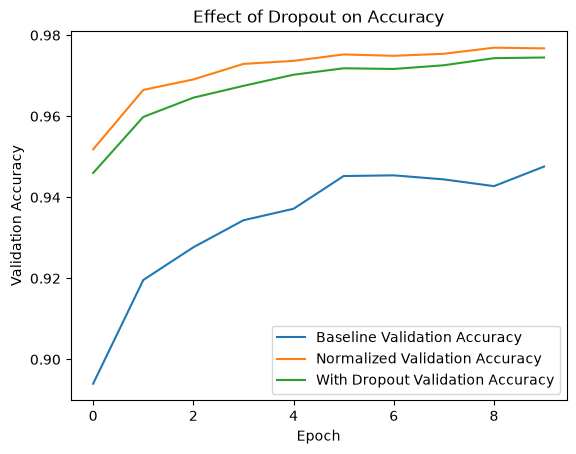

In [12]:
plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline Validation Accuracy'
)

plt.plot(
    history_norm_data.history['val_accuracy'],
    label='Normalized Validation Accuracy'
)

plt.plot(
    history_dropout.history['val_accuracy'],
    label='With Dropout Validation Accuracy'
)

plt.title('Effect of Dropout on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

# Create and train early-stopping model:

In [13]:
def create_model_with_early_stop():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(128, activation='relu'),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3
)

In [15]:
model_with_es = create_model_with_early_stop()

In [16]:
history_es = model_with_es.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9193 - loss: 0.2836 - val_accuracy: 0.9561 - val_loss: 0.1513
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9632 - loss: 0.1271 - val_accuracy: 0.9651 - val_loss: 0.1123
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9734 - loss: 0.0870 - val_accuracy: 0.9691 - val_loss: 0.1057
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9812 - loss: 0.0641 - val_accuracy: 0.9707 - val_loss: 0.0933
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9857 - loss: 0.0484 - val_accuracy: 0.9680 - val_loss: 0.1064
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9891 - loss: 0.0371 - val_accuracy: 0.9746 - val_loss: 0.0894
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9743 - val_loss: 0.0924
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9934 - loss:

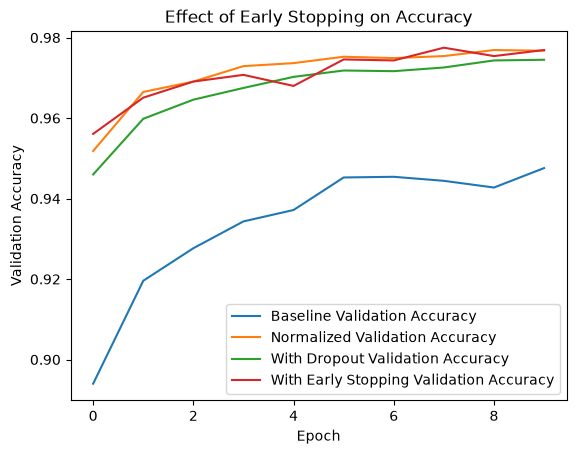

In [17]:
plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline Validation Accuracy'
)

plt.plot(
    history_norm_data.history['val_accuracy'],
    label='Normalized Validation Accuracy'
)

plt.plot(
    history_dropout.history['val_accuracy'],
    label='With Dropout Validation Accuracy'
)

plt.plot(
    history_es.history['val_accuracy'],
    label='With Early Stopping Validation Accuracy'
)

plt.title('Effect of Early Stopping on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

## Regularization:

#### Import Regularizers:

In [27]:
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1, l2, l1_l2
import matplotlib.pyplot as plt

## L1 model

In [29]:
def create_model_with_l1():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(
            128,
            activation='relu',
            kernel_regularizer=l1(0.0001)
        ),

        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### L2 model

In [28]:
def create_model_with_l2():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(
            128,
            activation='relu',
            kernel_regularizer=l2(0.0001)
        ),

        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
l1_l2(
    l1=0.0001,
    l2=0.0001
)

In [30]:
def create_model_with_l1_l2():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(
            128,
            activation='relu',
            kernel_regularizer=l1_l2(
                l1=0.0001,
                l2=0.0001
            )
        ),

        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Train all models:

In [31]:
model_with_l1 = create_model_with_l1()

history_l1 = model_with_l1.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8681 - loss: 0.6583 - val_accuracy: 0.9441 - val_loss: 0.3820
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9201 - loss: 0.4464 - val_accuracy: 0.9546 - val_loss: 0.3262
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9304 - loss: 0.4011 - val_accuracy: 0.9585 - val_loss: 0.3098
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9338 - loss: 0.3846 - val_accuracy: 0.9599 - val_loss: 0.3039
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9385 - loss: 0.3708 - val_accuracy: 0.9652 - val_loss: 0.2790
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9423 - loss: 0.3570 - val_accuracy: 0.9688 - val_loss: 0.2710
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9438 - loss: 0.3541 - val_accuracy: 0.9688 - val_loss: 0.2718
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9433 - loss: 0.3

In [33]:
model_with_l2 = create_model_with_l2()

history_l2 = model_with_l2.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8724 - loss: 0.4541 - val_accuracy: 0.9478 - val_loss: 0.2060
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9292 - loss: 0.2701 - val_accuracy: 0.9593 - val_loss: 0.1755
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9399 - loss: 0.2394 - val_accuracy: 0.9647 - val_loss: 0.1596
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9469 - loss: 0.2154 - val_accuracy: 0.9658 - val_loss: 0.1515
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9499 - loss: 0.2065 - val_accuracy: 0.9701 - val_loss: 0.1437
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9518 - loss: 0.2011 - val_accuracy: 0.9709 - val_loss: 0.1410
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9562 - loss: 0.1902 - val_accuracy: 0.9718 - val_loss: 0.1409
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9542 - loss: 0

In [36]:
model_with_l1_l2 = create_model_with_l1_l2()

history_l1_l2 = model_with_l1_l2.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8677 - loss: 0.6667 - val_accuracy: 0.9447 - val_loss: 0.3896
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9206 - loss: 0.4533 - val_accuracy: 0.9535 - val_loss: 0.3325
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9295 - loss: 0.4089 - val_accuracy: 0.9628 - val_loss: 0.3025
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9354 - loss: 0.3883 - val_accuracy: 0.9641 - val_loss: 0.2915
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9367 - loss: 0.3774 - val_accuracy: 0.9653 - val_loss: 0.2898
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9390 - loss: 0.3671 - val_accuracy: 0.9678 - val_loss: 0.2795
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9417 - loss: 0.3601 - val_accuracy: 0.9658 - val_loss: 0.2789
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9438 - loss: 0.3529 - 

## Plot Regularization results:

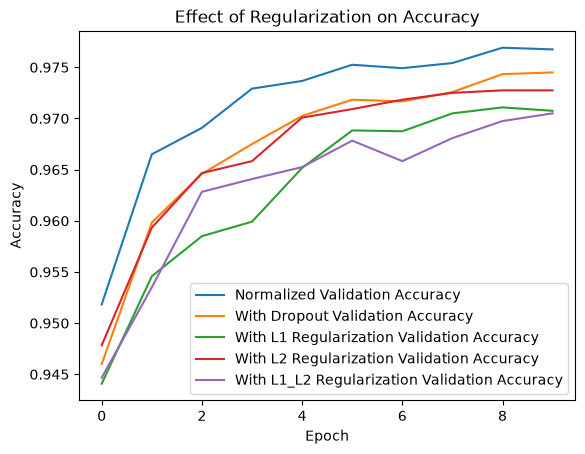

In [37]:
plt.plot(
    history_norm_data.history['val_accuracy'],
    label='Normalized Validation Accuracy'
)

plt.plot(
    history_dropout.history['val_accuracy'],
    label='With Dropout Validation Accuracy'
)

plt.plot(
    history_l1.history['val_accuracy'],
    label='With L1 Regularization Validation Accuracy'
)

plt.plot(
    history_l2.history['val_accuracy'],
    label='With L2 Regularization Validation Accuracy'
)

plt.plot(
    history_l1_l2.history['val_accuracy'],
    label='With L1_L2 Regularization Validation Accuracy'
)

plt.title('Effect of Regularization on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Second regularization graph:

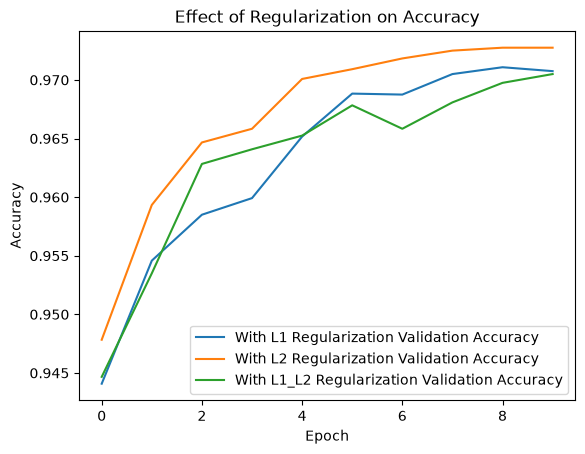

In [38]:
plt.plot(
    history_l1.history['val_accuracy'],
    label='With L1 Regularization Validation Accuracy'
)

plt.plot(
    history_l2.history['val_accuracy'],
    label='With L2 Regularization Validation Accuracy'
)

plt.plot(
    history_l1_l2.history['val_accuracy'],
    label='With L1_L2 Regularization Validation Accuracy'
)

plt.title('Effect of Regularization on Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **K FOLD :**

In [39]:
import numpy as np

from sklearn.model_selection import KFold

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

## Normalize the data:

In [42]:
(X_train, y_train), (x_test, y_test) = mnist.load_data()

X_train, x_test = X_train / 255.0, x_test / 255.0

## One hot encoding:

In [47]:
y_train_cat = to_categorical(y_train, 10)

## Model:

In [54]:
def create_kfold_model():

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        Dense(128, activation='relu'),

        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## K fold :

In [45]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [52]:
print(y_train.shape)

(60000, 10)


In [53]:
y_train_kfold = y_train

In [56]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracies = []
fold_losses = []

for fold, (train_index, val_index) in enumerate(kfold.split(X_train)):

    print(f"\n========== Fold {fold + 1} ==========")

    # Training data for this fold
    x_train_fold = X_train[train_index]
    y_train_fold = y_train_kfold[train_index]

    # Validation data for this fold
    x_val_fold = X_train[val_index]
    y_val_fold = y_train_kfold[val_index]

    # Create a NEW model
    model = create_kfold_model()

    # Train
    history = model.fit(
        x_train_fold,
        y_train_fold,
        epochs=10,
        batch_size=32,
        verbose=1
    )

    # Validate
    loss, accuracy = model.evaluate(
        x_val_fold,
        y_val_fold,
        verbose=0
    )

    fold_losses.append(loss)
    fold_accuracies.append(accuracy)

    print(f"Fold {fold + 1} Loss: {loss:.4f}")
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")


========== Fold 1 ==========
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8718 - loss: 0.4248
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9292 - loss: 0.2412
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9419 - loss: 0.1985
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9472 - loss: 0.1747
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9511 - loss: 0.1593
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9544 - loss: 0.1478
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9586 - loss: 0.1370
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9583 - loss: 0.1313
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9612 - loss: 0.1226
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9633 - loss: 0.1188
Fold 1 Loss: 0.0892
Fold 1 Accuracy: 0.9739

========== Fold 2 ==========
Epoch 1/10
1500

In [57]:
average_loss = np.mean(fold_losses)
average_accuracy = np.mean(fold_accuracies)

print("\n========== K-Fold Validation Results ==========")

print("Fold Accuracies:")
print(fold_accuracies)

print("\nFold Losses:")
print(fold_losses)

print(f"\nAverage Loss: {average_loss:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")


========== K-Fold Validation Results ==========
Fold Accuracies:
[0.9739166498184204, 0.9740833044052124, 0.9710833430290222, 0.9723333120346069, 0.9703333377838135]

Fold Losses:
[0.08918878436088562, 0.09056346863508224, 0.09784946590662003, 0.0987185388803482, 0.09813210368156433]

Average Loss: 0.0949
Average Accuracy: 0.9723


# *Best Accuracy*:

In [58]:
validation_scores = {
    "Baseline": max(history_baseline.history["val_accuracy"]),
    "Normalized": max(history_norm_data.history["val_accuracy"]),
    "Dropout": max(history_dropout.history["val_accuracy"]),
    "Early Stopping": max(history_es.history["val_accuracy"]),
    "L1 Regularization": max(history_l1.history["val_accuracy"]),
    "L2 Regularization": max(history_l2.history["val_accuracy"]),
    "L1 + L2 Regularization": max(history_l1_l2.history["val_accuracy"]),
}

best_model = max(validation_scores, key=validation_scores.get)

print("Validation accuracy of each model:")
for name, accuracy in validation_scores.items():
    print(f"{name}: {accuracy:.4f}")

print(f"\nBest model: {best_model}")
print(f"Best validation accuracy: {validation_scores[best_model]:.4f}")

Validation accuracy of each model:
Baseline: 0.9476
Normalized: 0.9769
Dropout: 0.9745
Early Stopping: 0.9775
L1 Regularization: 0.9711
L2 Regularization: 0.9728
L1 + L2 Regularization: 0.9705

Best model: Early Stopping
Best validation accuracy: 0.9775
